<div style="
display:flex;
align-items:center;
justify-content:center;
gap:20px;
padding:24px;
border-radius:16px;
background: linear-gradient(135deg, #1f1c2c, #928dab);
box-shadow: 0 6px 16px rgba(0,0,0,0.25);
">

  <img src="https://cdn-icons-png.flaticon.com/512/387/387561.png"
       width="80"
       style="background:white; padding:6px; border-radius:10px;" />

  <h1 style="
  color:white;
  font-size:32px;
  font-weight:bold;
  margin:0;
  text-align:center;
  white-space:nowrap;">
    🩺 Skin Cancer Classification with EfficientNet
  </h1>

</div>

# This project focuses on multi-class skin lesion classification using deep learning on the HAM10000 dataset. A pre-trained EfficientNet-B0 model was applied with transfer learning to classify different types of skin lesions from dermoscopic images.

<h1 style="
font-size:32px; 
font-weight:bold;
background: linear-gradient(90deg, #3a7bd5, #6a11cb, #1f1c2c);
-webkit-background-clip: text;
color: transparent;
text-align:center;">
 ________________________________________________
 </h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


from torchvision import models
from torchvision.models import ( efficientnet_b0, EfficientNet_B0_Weights)
import torch.optim as optim



In [2]:

print(torch.cuda.is_available())

True


In [3]:
data_dir = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

In [4]:
df = pd.read_csv(
    os.path.join(data_dir, "HAM10000_metadata.csv")
)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
image_paths = {}

for dirname, _, filenames in os.walk(data_dir):
    
    for filename in filenames:
        
        if filename.endswith(".jpg"):
            
            image_paths[filename[:-4]] = os.path.join(
                dirname,
                filename
            )



df["path"] = df["image_id"].map(image_paths.get)
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...


In [6]:
# df["path_exists"] = df["path"].apply(lambda x: os.path.exists(x))

#df["path_exists"].value_counts()
#df["path"].isnull().sum()



<div style="
background:#2c3e50;
color:white;
padding:12px 20px;
font-size:26px;
border-radius:8px;
margin:15px 0;
text-align:center;">
Exploratory Data Analysis
</div>


In [7]:
print(df.columns)
print("-------------------------------------------")
print(df.shape)

df.info()

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'path'],
      dtype='object')
-------------------------------------------
(10015, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   path          10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB


In [8]:
for col in df.columns:
    print(col, ":", df[col].nunique())



lesion_id : 7470
image_id : 10015
dx : 7
dx_type : 4
age : 18
sex : 3
localization : 15
path : 10015


In [9]:
df.isnull().sum().sort_values(ascending=False)


age             57
lesion_id        0
dx               0
image_id         0
dx_type          0
sex              0
localization     0
path             0
dtype: int64

In [10]:
print(df["dx"].unique())

['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


In [11]:
print(df["dx"].value_counts())
df["dx"].value_counts(normalize=True) * 100

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


dx
nv       66.949576
mel      11.113330
bkl      10.973540
bcc       5.132302
akiec     3.265102
vasc      1.417873
df        1.148278
Name: proportion, dtype: float64

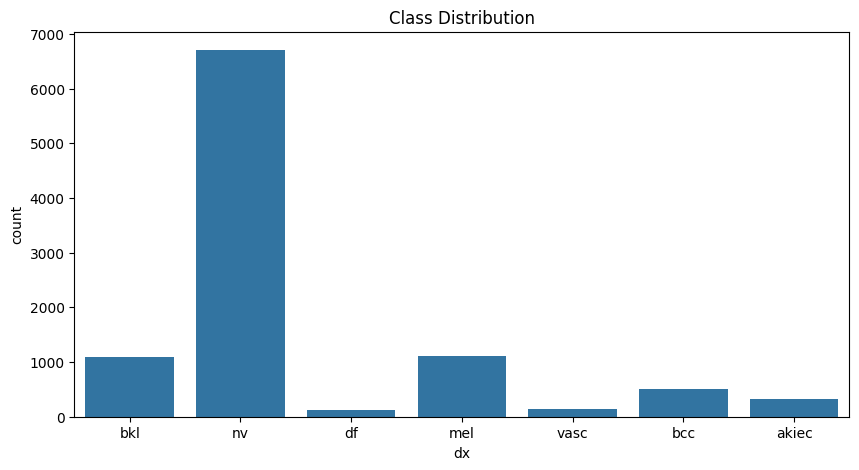

In [12]:

plt.figure(figsize=(10,5))

sns.countplot(x=df["dx"])

plt.title("Class Distribution")

plt.show()

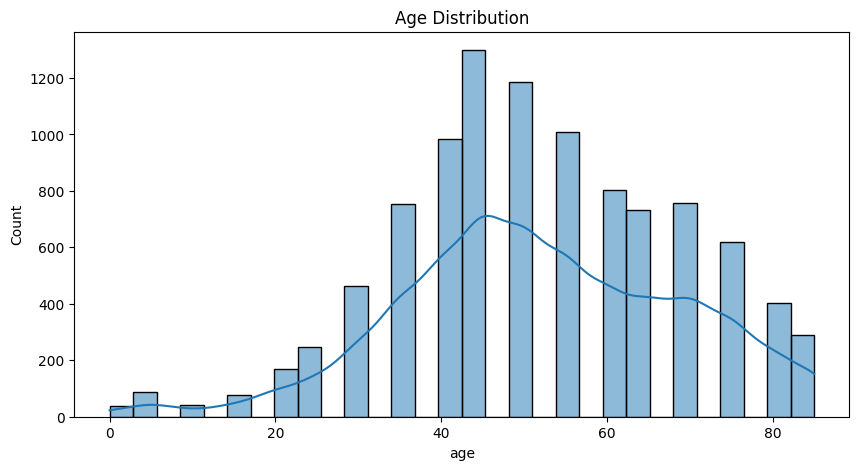

In [13]:

plt.figure(figsize=(10,5))
sns.histplot(df["age"].dropna(), bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

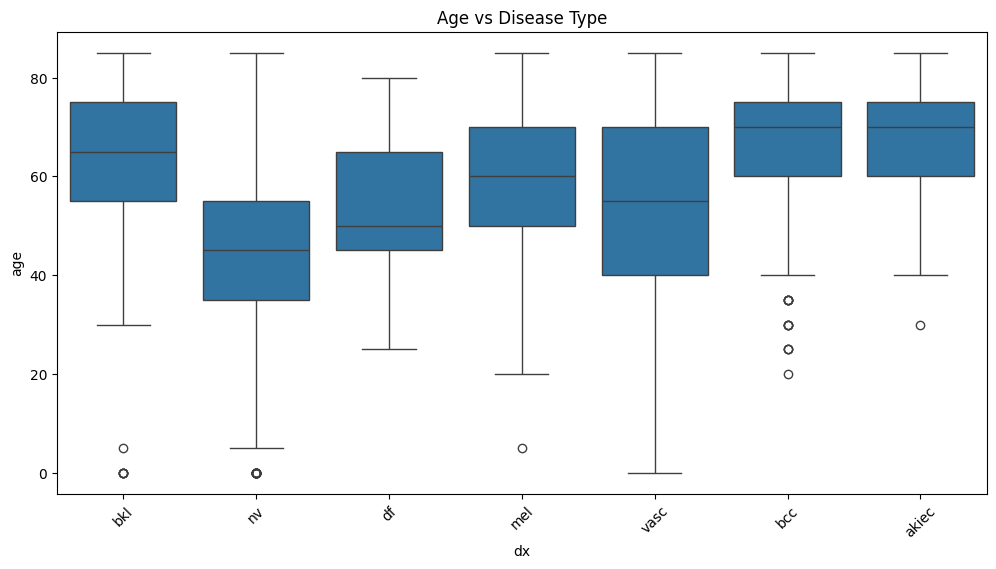

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(x="dx", y="age", data=df)

plt.title("Age vs Disease Type")
plt.xticks(rotation=45)
plt.show()

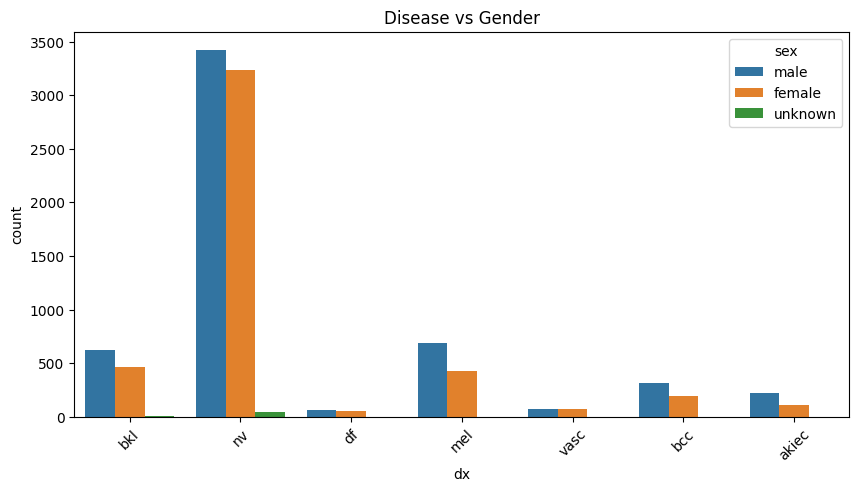

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(x="dx", hue="sex", data=df)

plt.xticks(rotation=45)
plt.title("Disease vs Gender")
plt.show()


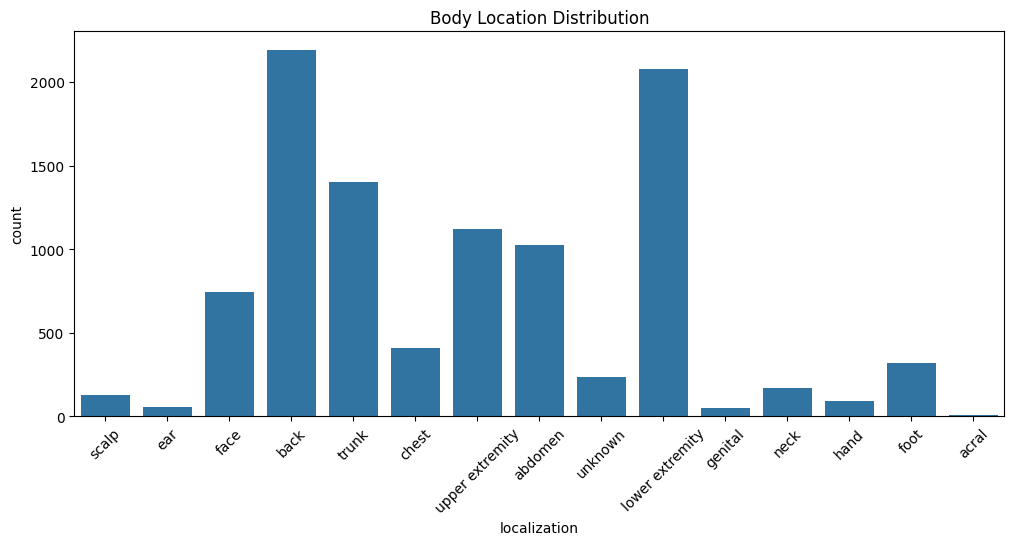

In [16]:
plt.figure(figsize=(12,5))

sns.countplot(x="localization", data=df)

plt.xticks(rotation=45)
plt.title("Body Location Distribution")
plt.show()

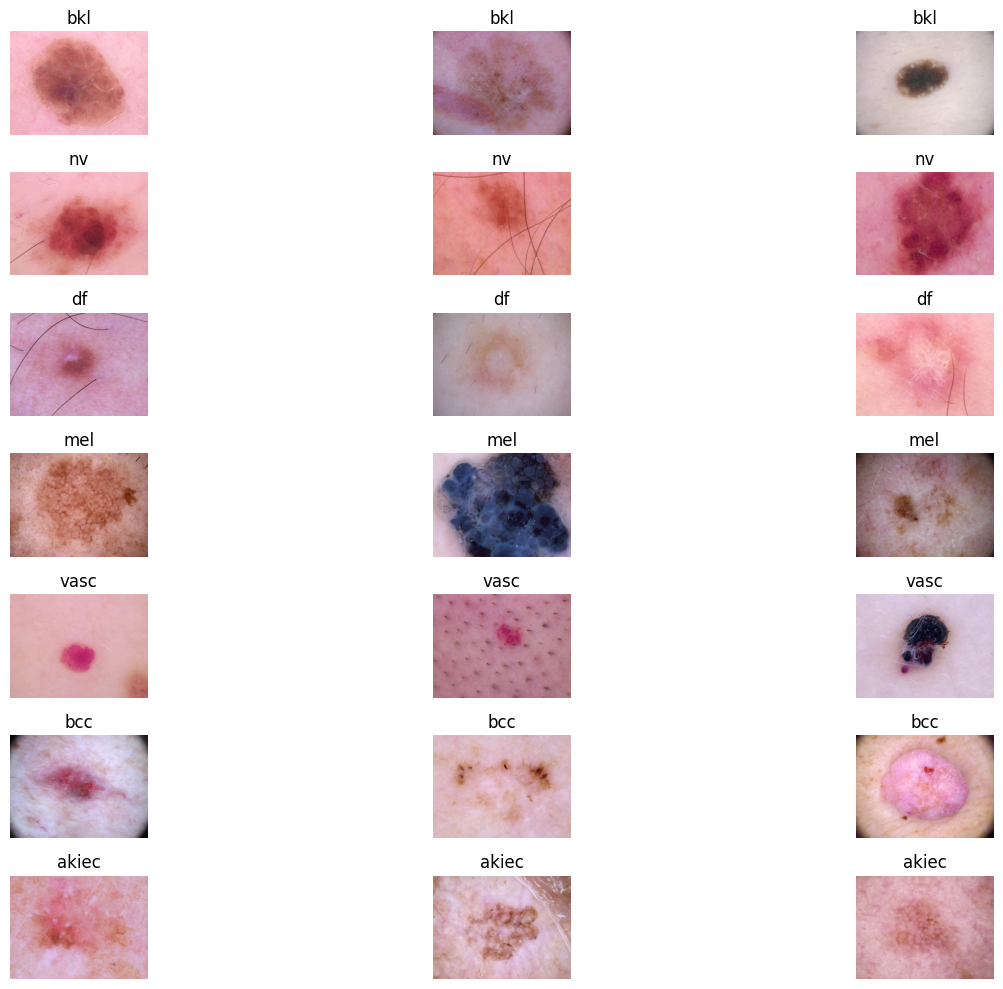

In [17]:
classes = df["dx"].unique()

plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):
    
    samples = df[df["dx"] == cls].sample(3)
    
    for j, row in enumerate(samples.itertuples()):
        
        img = cv2.imread(row.path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(len(classes), 3, i*3 +
                    j + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
sizes = []

for i in range(300):
    
    img = cv2.imread(df.iloc[i]["path"])
    
    sizes.append(img.shape[:2])

heights = [s[0] for s in sizes]
widths = [s[1] for s in sizes]

print("Avg Height:", sum(heights)/len(heights))
print("Avg Width:", sum(widths)/len(widths))

Avg Height: 450.0
Avg Width: 600.0


<div style="
background:#2c3e50;
color:white;
padding:12px 20px;
font-size:26px;
border-radius:8px;
margin:15px 0;
text-align:center;">
    Preprocessing the data

</div>

In [19]:
df["age"] = df["age"].fillna(df["age"].median())

In [20]:
df.isnull().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
path            0
dtype: int64

# Label Encoding

In [21]:
label_map = {
    "nv": 0,
    "mel": 1,
    "bkl": 2,
    "bcc": 3,
    "akiec": 4,
    "vasc": 5,
    "df": 6
}

df["label"] = df["dx"].map(label_map)

In [22]:
df[["dx", "label"]].head()

,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [23]:

# 80% Train
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# 10% Validation + 10% Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (8012, 9)
Validation: (1001, 9)
Test: (1002, 9)


In [24]:
print(train_df["dx"].value_counts())
print(val_df["dx"].value_counts())
print(test_df["dx"].value_counts())

dx
nv       5364
mel       890
bkl       879
bcc       411
akiec     262
vasc      114
df         92
Name: count, dtype: int64
dx
nv       670
mel      111
bkl      110
bcc       51
akiec     33
vasc      14
df        12
Name: count, dtype: int64
dx
nv       671
mel      112
bkl      110
bcc       52
akiec     32
vasc      14
df        11
Name: count, dtype: int64


In [25]:

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [26]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [27]:
class SkinDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        img_path = self.dataframe.iloc[idx]["path"]
        label = self.dataframe.iloc[idx]["label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [28]:
train_dataset = SkinDataset(train_df, transform=train_transform)

val_dataset = SkinDataset(val_df, transform=val_test_transform)

test_dataset = SkinDataset(test_df, transform=val_test_transform)

In [29]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

In [30]:
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

In [31]:
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [32]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([16, 3, 224, 224]) torch.Size([16])


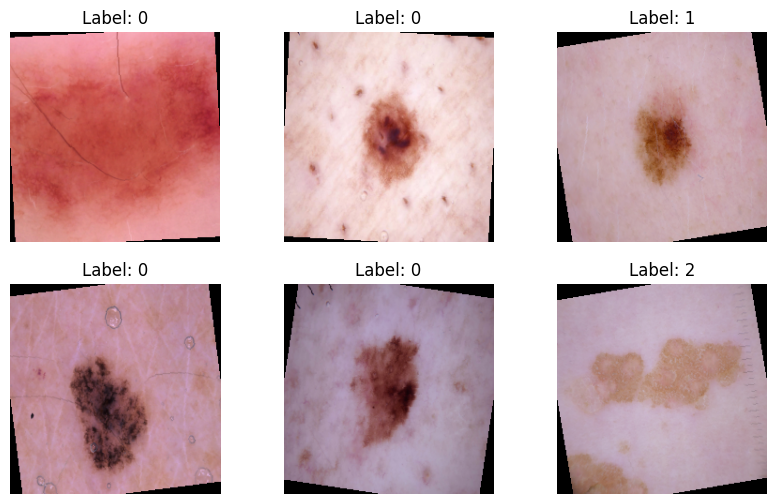

In [33]:

images, labels = next(iter(train_loader))

def show_batch(images, labels):

    plt.figure(figsize=(10,6))

    for i in range(6):

        img = images[i].cpu()

        #  Tensor 
        img = img.permute(1, 2, 0).numpy()

        # normalization
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]

        img = img.clip(0, 1)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)

        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")

    plt.show()

show_batch(images, labels)

<div style="
background:#2c3e50;
color:white;
padding:12px 20px;
font-size:26px;
border-radius:8px;
margin:15px 0;
text-align:center;">
  EfficientNet_B0 Model
</div>

In [34]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [35]:
from torchvision.models import ( efficientnet_b0, EfficientNet_B0_Weights)


model = efficientnet_b0( weights=EfficientNet_B0_Weights.DEFAULT)
print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 135MB/s] 


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [36]:
#print(model)

In [37]:
model.classifier[1] = nn.Linear(
    in_features=1280,
    out_features=7
)

In [38]:
model = model.to(device)

In [39]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(  model.parameters(),   lr=0.001)

In [40]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([16, 7])


In [41]:
_, preds = torch.max(outputs, 1)

print(preds)

tensor([4, 1, 0, 3, 1, 5, 4, 0, 1, 6, 5, 0, 6, 4, 0, 6], device='cuda:0')


In [42]:
num_epochs = 30

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Forward Pass
        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")


Epoch [1/30] Loss: 0.7390
Epoch [2/30] Loss: 0.5984
Epoch [3/30] Loss: 0.5229
Epoch [4/30] Loss: 0.4898
Epoch [5/30] Loss: 0.4550
Epoch [6/30] Loss: 0.4107
Epoch [7/30] Loss: 0.3878
Epoch [8/30] Loss: 0.3522
Epoch [9/30] Loss: 0.3239
Epoch [10/30] Loss: 0.3170
Epoch [11/30] Loss: 0.2904
Epoch [12/30] Loss: 0.2616
Epoch [13/30] Loss: 0.2547
Epoch [14/30] Loss: 0.2293
Epoch [15/30] Loss: 0.2196
Epoch [16/30] Loss: 0.1898
Epoch [17/30] Loss: 0.1994
Epoch [18/30] Loss: 0.1627
Epoch [19/30] Loss: 0.1652
Epoch [20/30] Loss: 0.1559
Epoch [21/30] Loss: 0.1418
Epoch [22/30] Loss: 0.1515
Epoch [23/30] Loss: 0.1293
Epoch [24/30] Loss: 0.1287
Epoch [25/30] Loss: 0.1168
Epoch [26/30] Loss: 0.1237
Epoch [27/30] Loss: 0.1124
Epoch [28/30] Loss: 0.1085
Epoch [29/30] Loss: 0.0977
Epoch [30/30] Loss: 0.1071


In [43]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 86.11%


In [44]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [45]:
len(all_preds), len(all_labels)

(1001, 1001)

In [46]:

class_names = [
    "nv",
    "mel",
    "bkl",
    "bcc",
    "akiec",
    "vasc",
    "df"
]

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

          nv       0.92      0.96      0.94       670
         mel       0.63      0.60      0.61       111
         bkl       0.74      0.68      0.71       110
         bcc       0.90      0.73      0.80        51
       akiec       0.81      0.64      0.71        33
        vasc       0.65      0.93      0.76        14
          df       0.90      0.75      0.82        12

    accuracy                           0.86      1001
   macro avg       0.79      0.75      0.77      1001
weighted avg       0.86      0.86      0.86      1001



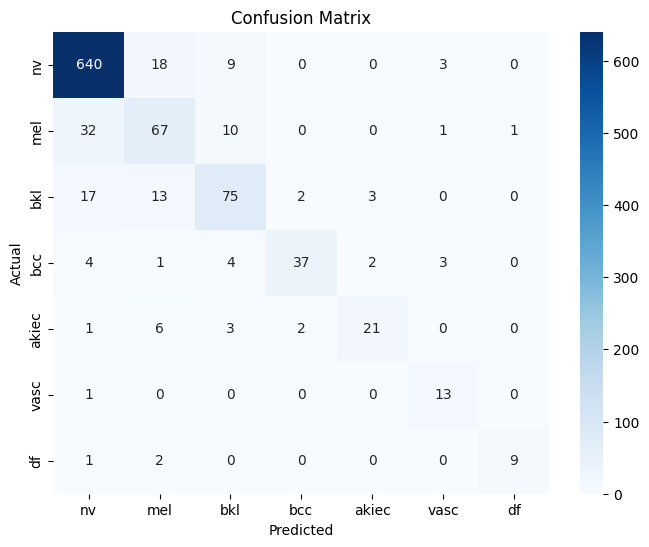

In [47]:

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [48]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 86.23%


In [49]:
model.eval()

test_preds = []
test_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

In [50]:

class_names = [
    "nv",
    "mel",
    "bkl",
    "bcc",
    "akiec",
    "vasc",
    "df"
]

print(
    classification_report(
        test_labels,
        test_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

          nv       0.93      0.94      0.93       671
         mel       0.72      0.68      0.70       112
         bkl       0.73      0.69      0.71       110
         bcc       0.78      0.69      0.73        52
       akiec       0.79      0.72      0.75        32
        vasc       0.48      0.93      0.63        14
          df       0.80      0.73      0.76        11

    accuracy                           0.86      1002
   macro avg       0.75      0.77      0.75      1002
weighted avg       0.86      0.86      0.86      1002



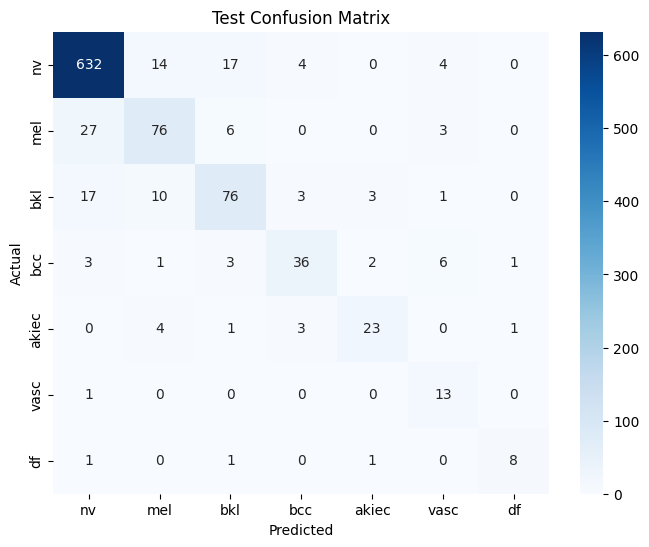

In [51]:


cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix")

plt.show()

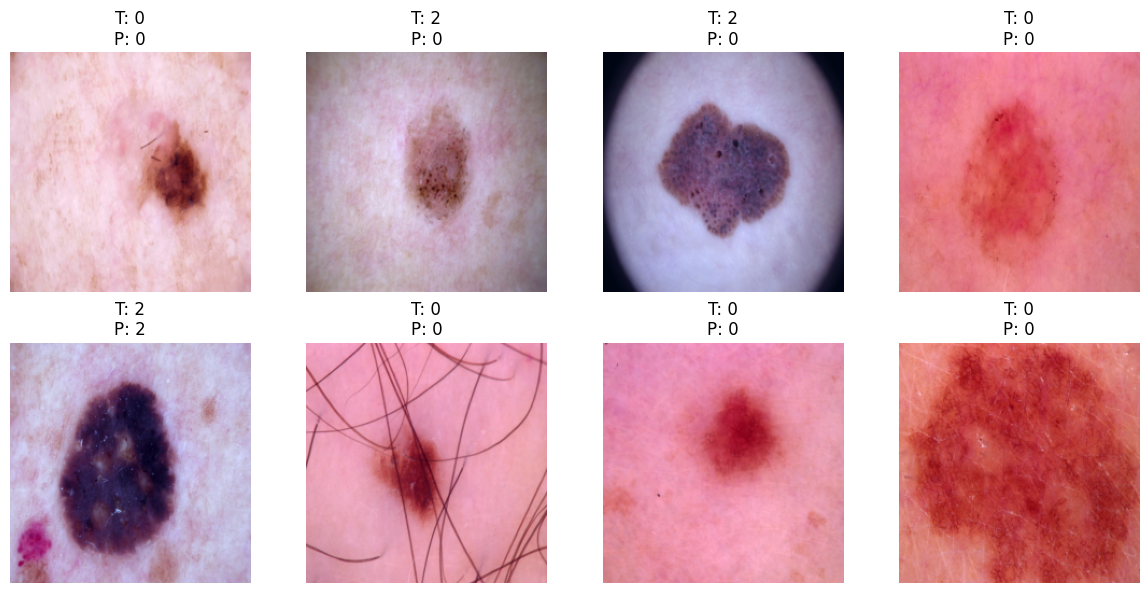

In [52]:
class_names = list(label_map.values())

def show_samples(images, labels, preds, n=8):

    plt.figure(figsize=(12,6))

    for i in range(n):

        img = images[i].permute(1,2,0).cpu().numpy()

        img = (img - img.min()) / (img.max() - img.min())

        plt.subplot(2,4,i+1)
        plt.imshow(img)

        true_label = class_names[labels[i]]
        pred_label = class_names[preds[i]]

        plt.title(f"T: {true_label}\nP: {pred_label}")

        plt.axis("off")

    plt.tight_layout()
    plt.show()


images, labels = next(iter(val_loader))

images = images.to(device)

outputs = model(images)

_, preds = torch.max(outputs, 1)

show_samples(images, labels, preds)

<div style="
background:green;
padding:20px;
border-radius:12px;
box-shadow:0 4px 10px rgba(0,0,0,0.15);
font-size:34px;
font-weight:bold;
text-align:center;
color:white;">
    Conclusion
</div>


# This project used EfficientNet-B0 with transfer learning to classify skin lesions from the HAM10000 dataset. After proper preprocessing and training, the model achieved 87% validation accuracy and 86% test accuracy, showing strong and stable performance. 

<h1 style="
font-size:32px; 
font-weight:bold;
background: linear-gradient(90deg, #3a7bd5, #6a11cb, #1f1c2c);
-webkit-background-clip: text;
color: transparent;
text-align:center;">
 ________________________________________________
 </h1>